## Imports

In [21]:
from itertools import zip_longest

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from tqdm.notebook import tqdm
from umap import UMAP

from analysis_helpers import Episode, Participant

## Classes/functions

In [2]:
class Circle:
    def __init__(self, center, radius):
        self.center = np.asarray(center)
        self.radius = radius

In [3]:
class LineSegment:  
    def __init__(self, point1, point2):
        self.p1 = np.asarray(point1)
        self.p2 = np.asarray(point2)
        self.vec = self.p2 - self.p1
        self.norm = self.vec / np.linalg.norm(self.vec)
        
    def __repr__(self):
        return f'{self.__class__.__name__}({str(self.p1)} -> {str(self.p2)})'
    
    @property
    def angle(self):
        p1 = np.zeros_like(self.p1)
        p2 = np.zeros_like(self.p1)
        p2[0] = 1
        ref = LineSegment(p1, p2)
        return self.angle_with(ref)
    
    def intersects(self, z):
        if not isinstance(z, Circle):
            raise TypeError(f"'z' must be a Circle, received '{type(z)}'")

        q = z.center
        r = z.radius
        a = self.vec.dot(self.vec)
        b = 2 * self.vec.dot(self.p1 - q)
        c = self.p1.dot(self.p1) + q.dot(q) - 2 * self.p1.dot(q) - r ** 2
        disc = b ** 2 - 4 * a * c
        if disc < 0:
            return False

        sqrt_disc = disc ** 0.5
        t1 = (-b + sqrt_disc) / (2 * a)
        t2 = (-b - sqrt_disc) / (2 * a)
        if 0 <= t1 <= 1 or 0 <= t2 <= 1:
            return True
        
        return False
            
    def angle_with(self, ref):
        if not isinstance(ref, LineSegment):
            raise TypeError(f"'ref' must be a LineSegment, received '{type(ref)}'")

        v0 = ref.vec
        v1 = self.vec
        angle = np.arccos(v0.dot(v1) / (np.linalg.norm(v0) * np.linalg.norm(v1)))
        if self.vec[1] < 0:
            angle = (2 * np.pi) - angle
        
        return angle

In [120]:
def rayleigh_test(angles):
    """Rayleigh test for non-uniformity of circular data."""
    # note: angles is expected in radians
    n = angles.size
    r = np.abs(np.exp(1j * angles).mean())   # mean resultant length
    R = n * r
    z = n * r ** 2
    pval = np.exp(np.sqrt(1 + 4 * n + 4 * (n ** 2 - R ** 2)) - (1 + 2 * n))
    return z, pval

In [119]:
def compute_coord_stats(xi, yi, width, seglist):
    circ = Circle(center=[xi, yi], radius=width)
    segs = [s for s in seglist if s.intersects(circ)]
    n_intersects = len(segs)
    if n_intersects > 1:
        u, v = np.array([seg.norm for seg in segs]).mean(axis=0)
        rads = np.array([seg.angle for seg in segs])
        z, p = rayleigh_test(rads)
    else:
        u, v, z, p = 0, 0, 0, 1
    
    return u, v, z, p, n_intersects

In [6]:
def add_arrows(axes, x, y, **kwargs):
    # spacing of arrows
    aspace = 1.5
    # distance spanned between pairs of points
    r = [0]
    for i in range(1, len(x)):
        dx = x[i] - x[i - 1]
        dy = y[i] - y[i - 1]
        r.append(np.sqrt(dx * dx + dy * dy))

    r = np.array(r)
    # cumulative sum of r, used to save time
    rtot = []
    for i in range(len(r)):
        rtot.append(r[0:i].sum())
    rtot.append(r.sum())
    # will hold tuple(x, y, theta) for each arrow
    arrow_data = []
    # current point on walk along data
    arrow_pos = 0
    rcount = 1
    while arrow_pos < r.sum():
        x1, x2 = x[rcount - 1], x[rcount]
        y1, y2 = y[rcount - 1], y[rcount]
        da = arrow_pos - rtot[rcount]
        theta = np.arctan2((x2 - x1), (y2 - y1))
        ax = np.sin(theta) * da + x1
        ay = np.cos(theta) * da + y1
        arrow_data.append((ax, ay, theta))
        arrow_pos += aspace
        while arrow_pos > rtot[rcount + 1]:
            rcount += 1
            if arrow_pos > rtot[-1]:
                break

    for ax, ay, theta in arrow_data:
        # use aspace as a guide for size and length of things
        # scaling factors were chosen by experimenting a bit
        axes.arrow(ax,
                   ay,
                   np.sin(theta) * aspace / 10,
                   np.cos(theta) * aspace / 10,
                   head_width=aspace / 3,
                   **kwargs)
        
        
# def add_arrows(axes, x, y, minifig=False, **kwargs):
#     if minifig:
#         aspace = 0.1
#     else:
#         aspace = .05

#     aspace *= scale

#     r = [0]
#     for i in range(1, len(x)):
#         dx = x[i] - x[i - 1]
#         dy = y[i] - y[i - 1]
#         r.append(np.sqrt(dx * dx + dy * dy))
#     r = np.array(r)

#     rtot = []
#     for i in range(len(r)):
#         rtot.append(r[0:i].sum())
#     rtot.append(r.sum())

#     arrowData = []
#     arrowPos = 0
#     rcount = 1
#     while arrowPos < r.sum():
#         x1, x2 = x[rcount - 1], x[rcount]
#         y1, y2 = y[rcount - 1], y[rcount]
#         da = arrowPos - rtot[rcount]
#         theta = np.arctan2((x2 - x1), (y2 - y1))
#         ax = np.sin(theta) * da + x1
#         ay = np.cos(theta) * da + y1
#         arrowData.append((ax, ay, theta))
#         arrowPos += aspace
#         while arrowPos > rtot[rcount + 1]:
#             rcount += 1
#             if arrowPos > rtot[-1]:
#                 break

#     for ax, ay, theta in arrowData:
#         axes.arrow(ax, ay,
#                    np.sin(theta) * aspace / 10, np.cos(theta) * aspace / 10,
#                    head_width=aspace / 3, **kwargs)

## Load data

In [7]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()
avg_participant = Participant('average')

## Project events to 2D

In [185]:
UMAP_PARAMS = {
    'n_neighbors': 15,
    'n_components': 2,
    'metric': 'cosine',
    'output_metric': 'euclidean',
    'random_state': 0,
    'verbose': True
}

In [192]:
to_reduce = [atlep1.events]
for rectype in ('atlep1', 'delayed'):
    to_reduce.append(avg_participant.events[rectype])
    for p in participants:
        to_reduce.append(p.events[rectype])
        
split_inds = np.cumsum([vec.shape[0] for vec in to_reduce])[:-1]

reducer = UMAP(**UMAP_PARAMS)
embeddings = reducer.fit_transform(np.vstack(to_reduce))

split_embeddings = np.vsplit(embeddings, split_inds)


atlep1.path_2d = split_embeddings[0]
split_ix = 1
for rectype in ('atlep1', 'delayed'):
    avg_participant.paths_2d[rectype] = split_embeddings[split_ix]
    split_ix += 1
    for p in participants:
        p.paths_2d[rectype] = split_embeddings[split_ix]
        split_ix += 1

/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=0, verbose=True)
Tue Jun 23 23:15:17 2026 Construct fuzzy simplicial set
Tue Jun 23 23:15:20 2026 Finding Nearest Neighbors
Tue Jun 23 23:15:20 2026 Finished Nearest Neighbor Search
Tue Jun 23 23:15:21 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Jun 23 23:15:23 2026 Finished embedding


## Turn 2D recall event paths into sets of line segments

In [193]:
seglists = {'atlep1': [], 'delayed': []}

for rectype in ('atlep1', 'delayed'):
    for p in participants:
        path_2d = p.paths_2d[rectype]
        for i in range(path_2d.shape[0] - 1):
            seg = LineSegment(path_2d[i], path_2d[i + 1])
            seglists[rectype].append(seg)

## Construct 2D grid over embedding space

In [194]:
# amount to pad grid edges beyond (first int past) extreme points
GRID_PAD = 0
# number of gridlines along shorter axis, used to derive x- & y-step size
GRID_RESOLUTION = 30

In [195]:
x_min, y_min = embeddings.min(axis=0).astype(int) - 1 - GRID_PAD
x_max, y_max = embeddings.max(axis=0).astype(int) + 1 + GRID_PAD

x_range, y_range = x_max - x_min, y_max - y_min
grid_step = min(x_range, y_range) / (GRID_RESOLUTION - 1)

# expand longer axis symmetrically to fit integer # of grid cells
# (subtract small value to protect against float division adding extra 
# grid line to shorter axis)
n_gridlines_x = int(np.ceil(x_range / grid_step - 1e-9)) + 1
n_gridlines_y = int(np.ceil(y_range / grid_step - 1e-9)) + 1
x_overshoot = (n_gridlines_x - 1) * grid_step - x_range 
y_overshoot = (n_gridlines_y - 1) * grid_step - y_range

xs = np.linspace(x_min - x_overshoot / 2, x_max + x_overshoot / 2, n_gridlines_x, endpoint=True)
ys = np.linspace(y_min - y_overshoot / 2, y_max + y_overshoot / 2, n_gridlines_y, endpoint=True)

X, Y = np.meshgrid(xs, ys)
# xy_grid = np.stack([X, Y], axis=-1)

## Compute average transition vector & stats at each grid point

In [196]:
grid_stats = {}
fwer_threshold = 0.05

pbar = tqdm(total=X.size*2, leave=False)
for rectype in ('atlep1', 'delayed'):
    U, V, Z, P, N = np.zeros((5, *X.shape))
    for i, j in np.ndindex(X.shape):
        u, v, z, p, n = compute_coord_stats(X[i, j], 
                                            Y[i, j], 
                                            width=grid_step*2, 
                                            seglist=seglists[rectype])
        U[i, j], V[i, j], Z[i, j], P[i, j], N[i, j] = u, v, z, p, n
        
        pbar.update()
        
    # correct for multiple comaprisons
    P_corrected = multipletests(P.ravel(), method='fdr_bh', alpha=fwer_threshold)[1]
    P_corrected = P_corrected.reshape(P.shape)
    
    arrow_lengths = np.hypot(U, V)
    arrow_colors = plt.cm.Blues(arrow_lengths)
    # not significant after multiple comparisons correction; color grey
    arrow_colors[P_corrected >= fwer_threshold] = [.5, .5, .5, .25]
    # no paths pass through region; color transparent
    arrow_colors[P == 1] = [.5, .5, .5, 0]

    grid_stats[rectype] = {
        'U': U, 
        'V': V, 
        'Z': Z, 
        'P': P, 
        'P_corrected': P_corrected,
        'arrow_colors': arrow_colors,
        'n_intersections': N
    }
pbar.close()

  0%|          | 0/2340 [00:00<?, ?it/s]

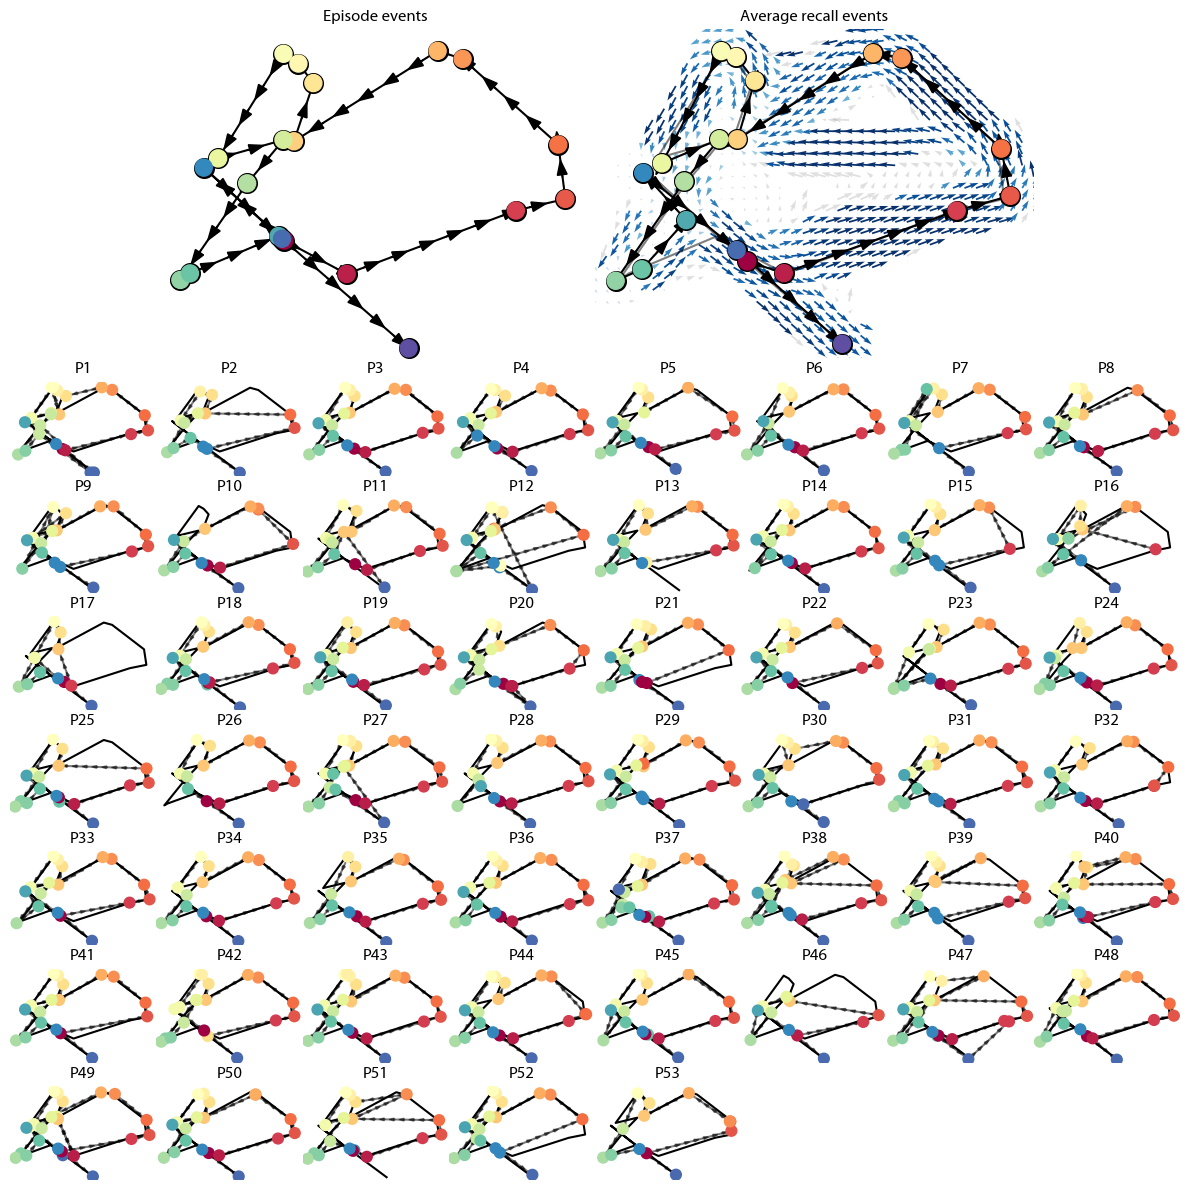

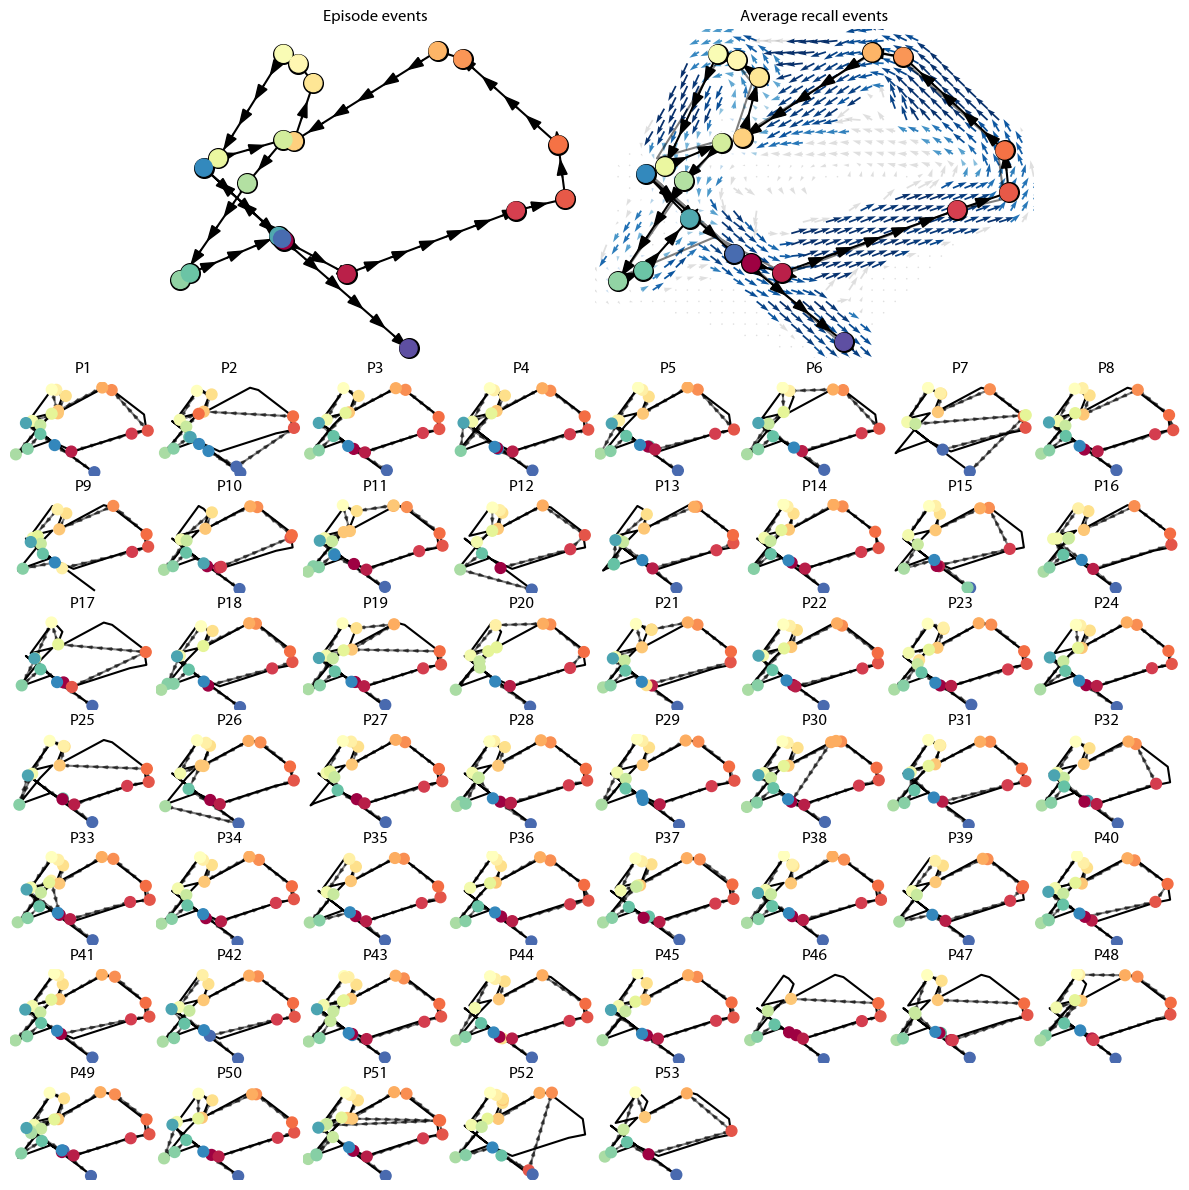

In [197]:
CMAP = plt.cm.Spectral

N_COLS = 8
EPISODE_AVGREC_ROWSCOLS = 3
N_ROWS = len(participants) // N_COLS + 1 + EPISODE_AVGREC_ROWSCOLS

for rectype in ('atlep1', 'delayed'):
    plt.figure(figsize=(12, 12))
    
    episode_ax = plt.subplot2grid(shape=(N_ROWS, N_COLS), 
                                  loc=(0, 1), 
                                  colspan=EPISODE_AVGREC_ROWSCOLS, 
                                  rowspan=EPISODE_AVGREC_ROWSCOLS)
    avgrec_ax = plt.subplot2grid(shape=(N_ROWS, N_COLS), 
                                  loc=(0, 4), 
                                  colspan=EPISODE_AVGREC_ROWSCOLS, 
                                  rowspan=EPISODE_AVGREC_ROWSCOLS)
    
    rec_axes = []
    for row_loc in range(EPISODE_AVGREC_ROWSCOLS, N_ROWS):
        for col_loc in range(N_COLS):
            ax = plt.subplot2grid(shape=(N_ROWS, N_COLS), loc=(row_loc, col_loc))
            rec_axes.append(ax)
            
    # plot episode trajectory and events
    episode_ax.plot(atlep1.path_2d[:, 0], 
                    atlep1.path_2d[:, 1], 
                    c='k', 
                    alpha=1, 
                    zorder=1)
    add_arrows(episode_ax, 
               atlep1.path_2d[:, 0], 
               atlep1.path_2d[:, 1], 
               color='k', 
               alpha=1, 
               fill=True, 
               zorder=1)
    episode_ax.scatter(atlep1.path_2d[:, 0], 
                       atlep1.path_2d[:, 1], 
                       s=200, 
                       c='k', 
                       zorder=2)
    episode_ax.scatter(atlep1.path_2d[:, 0], 
                       atlep1.path_2d[:, 1], 
                       s=150, 
                       c=range(atlep1.path_2d.shape[0]),
                       cmap=CMAP,
                       zorder=3)
    episode_ax.set_title('Episode events')
    episode_ax.set_xlim(X.min(), X.max())
    episode_ax.set_ylim(Y.min(), Y.max())
    episode_ax.axis('off')
#     episode_ax.text(0, 1, 'A', horizontalalignment='center', transform=axarr[0].transAxes, fontsize=18)

    U, V, arrow_colors = (grid_stats[rectype]['U'], 
                          grid_stats[rectype]['V'], 
                          grid_stats[rectype]['arrow_colors'])

    # plot average recall events
    avgrec_ax.quiver(X, Y, 
                     U, V, 
                     color=arrow_colors.reshape(-1, arrow_colors.shape[-1]), 
                     width=.004, 
                     zorder=1)
    avgrec_ax.plot(atlep1.path_2d[:, 0], 
                   atlep1.path_2d[:, 1], 
                   c='k', 
                   alpha=0.5, 
                   zorder=2)
    avgrec_ax.plot(avg_participant.paths_2d[rectype][:, 0], 
                   avg_participant.paths_2d[rectype][:, 1],
                   c='k',
                   alpha=1, 
                   zorder=3)
    add_arrows(avgrec_ax, 
               avg_participant.paths_2d[rectype][:, 0], 
               avg_participant.paths_2d[rectype][:, 1], 
               color='k', 
               alpha=1, 
               fill=True, 
               zorder=3)
    avgrec_ax.scatter(avg_participant.paths_2d[rectype][:, 0], 
                      avg_participant.paths_2d[rectype][:, 1], 
                      s=200,
                      c='k',
                      zorder=4)
    avgrec_ax.scatter(avg_participant.paths_2d[rectype][:, 0], 
                      avg_participant.paths_2d[rectype][:, 1], 
                      s=150, 
                      c=range(avg_participant.paths_2d[rectype].shape[0]), 
                      cmap=CMAP,
                      zorder=5)
    avgrec_ax.set_title('Average recall events')
    avgrec_ax.set_xlim(X.min(), X.max())
    avgrec_ax.set_ylim(Y.min(), Y.max())
    avgrec_ax.axis('off')
#     avgrec_ax.text(0, 1, 'B',
#                   horizontalalignment='center',
#                   transform=axarr[1].transAxes,
#                   fontsize=18)


    # plot individual recalls
#     axarr[2].text(0, 1.05, 'C', horizontalalignment='center', transform=axarr[2].transAxes, fontsize=18)

    for p, ax in zip_longest(participants, rec_axes):
        ax.axis('off')
        
        if p is None:
            continue
            
        ax.plot(atlep1.path_2d[:, 0], 
                atlep1.path_2d[:, 1], 
                c='k', 
                alpha=1, 
                zorder=1)
        ax.plot(p.paths_2d[rectype][:, 0], 
                p.paths_2d[rectype][:, 1], 
                c='k', 
                alpha=0.5, 
                zorder=2)
        add_arrows(ax, 
                   p.paths_2d[rectype][:, 0], 
                   p.paths_2d[rectype][:, 1], 
                   color='k', 
                   alpha=0.5, 
                   fill=True, 
                   zorder=2)
        ax.scatter(p.paths_2d[rectype][:, 0], 
                   p.paths_2d[rectype][:, 1], 
                   s=60,
                   c=CMAP(p.event_matches[rectype] / atlep1.events.shape[0]), 
#                    cmap=CMAP, 
                   zorder=3)
#         ax.set_box_aspect(X.shape[0]/X.shape[1])
        ax.set_title(f'P{p.sub_n}')
        ax.set_xlim(X.min(), X.max())
        ax.set_ylim(Y.min(), Y.max())

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0.25)
#     plt.savefig(FIG_DIR / f'{rectype}-paths2d.pdf', bbox_inches='tight')
    plt.show()

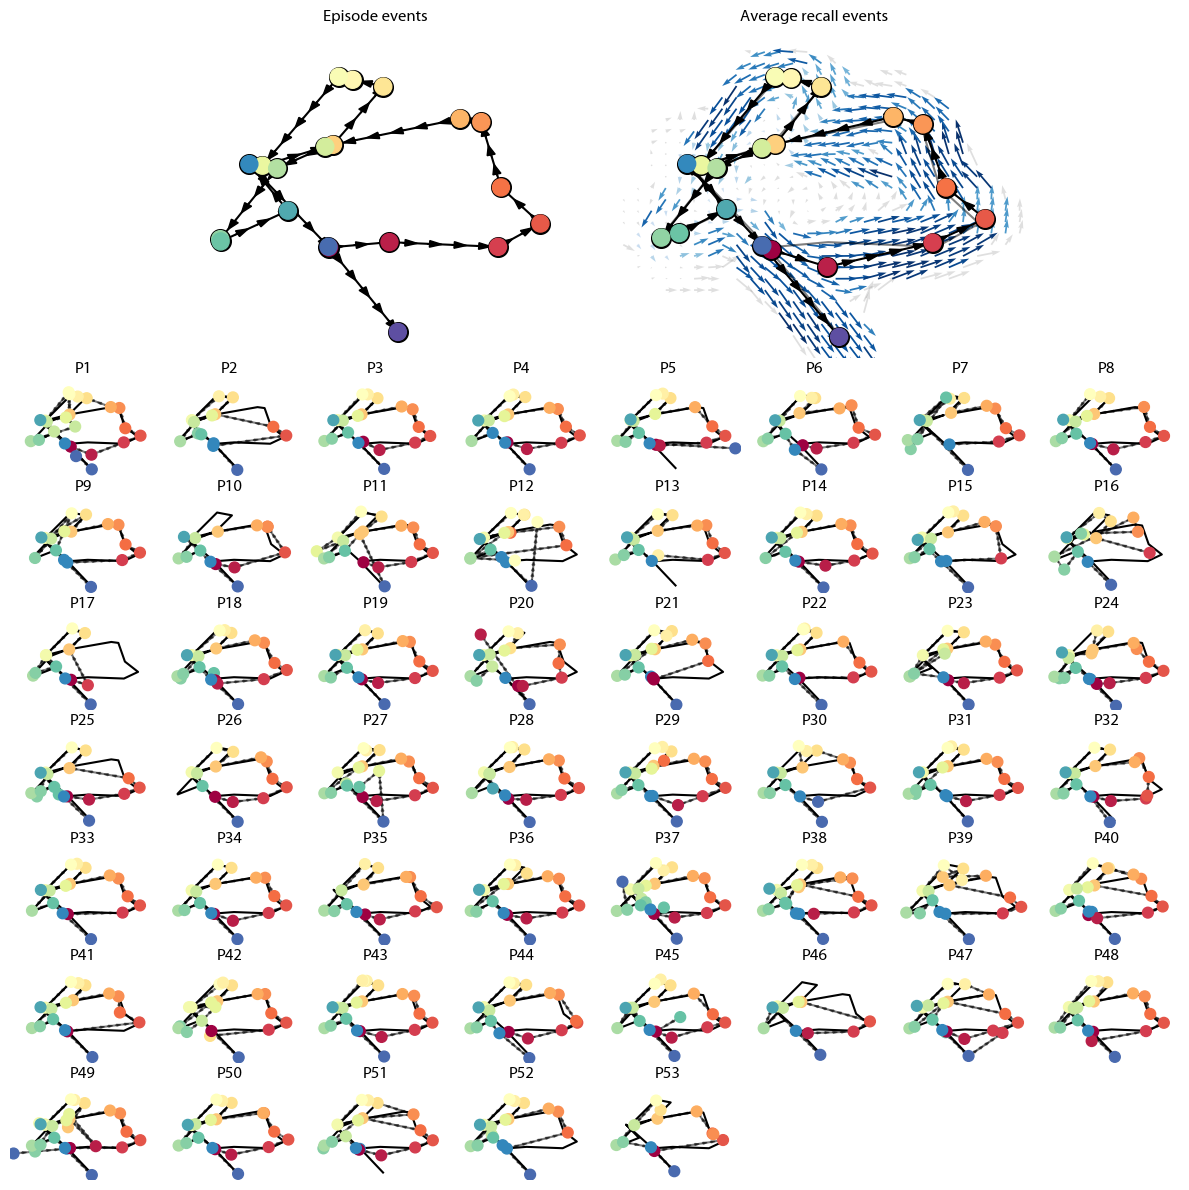

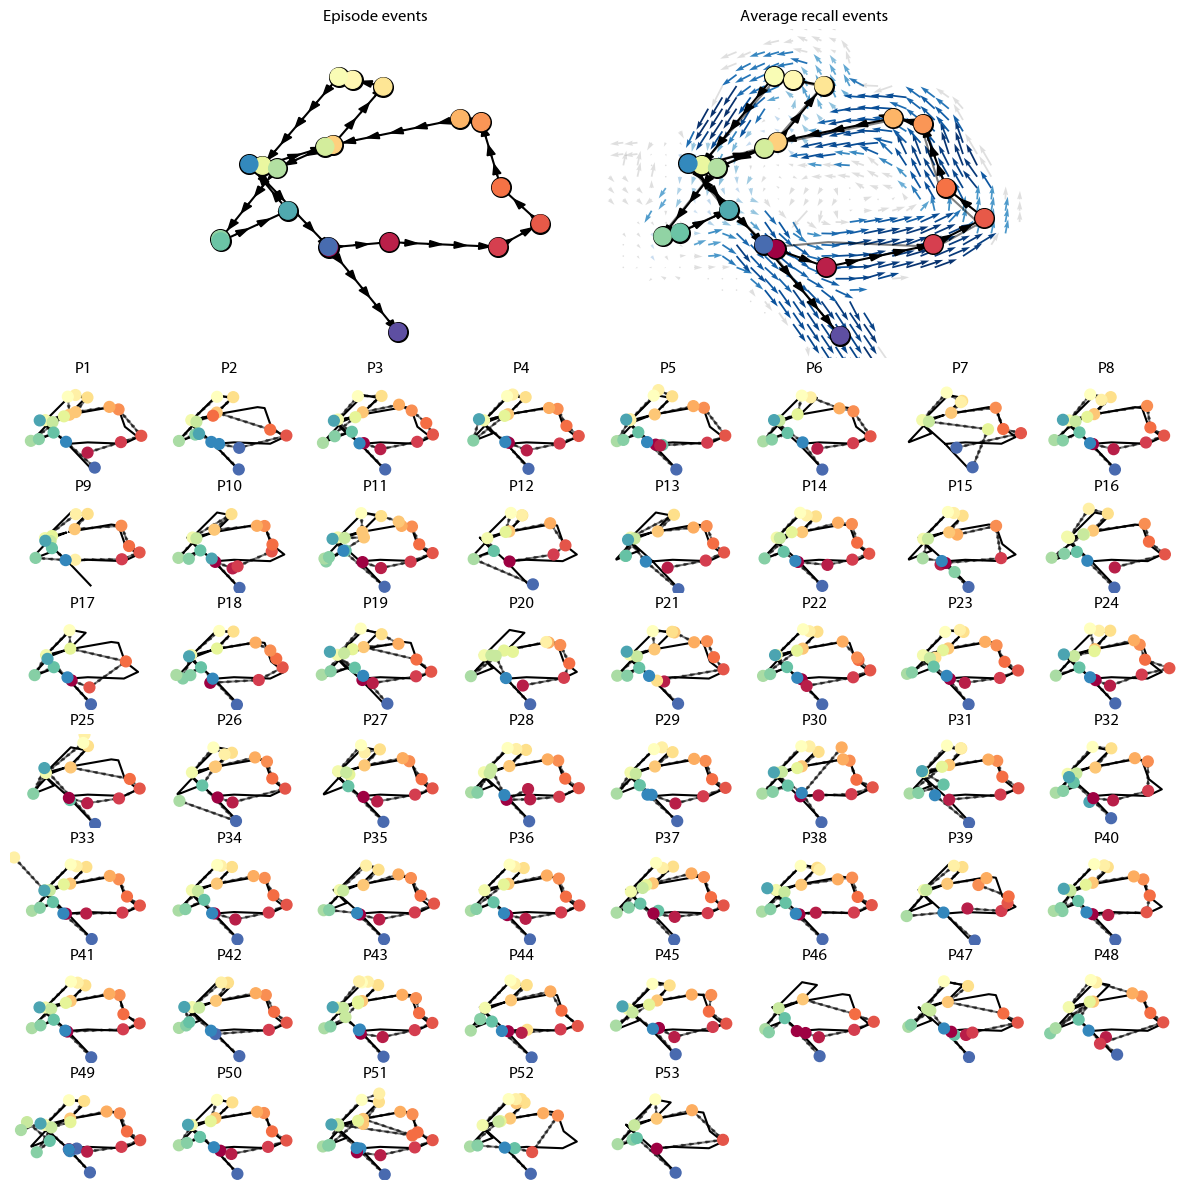

In [191]:
CMAP = plt.cm.Spectral

N_COLS = 8
EPISODE_AVGREC_ROWSCOLS = 3
N_ROWS = len(participants) // N_COLS + 1 + EPISODE_AVGREC_ROWSCOLS

for rectype in ('atlep1', 'delayed'):
    plt.figure(figsize=(12, 12))
    
    episode_ax = plt.subplot2grid(shape=(N_ROWS, N_COLS), 
                                  loc=(0, 1), 
                                  colspan=EPISODE_AVGREC_ROWSCOLS, 
                                  rowspan=EPISODE_AVGREC_ROWSCOLS)
    avgrec_ax = plt.subplot2grid(shape=(N_ROWS, N_COLS), 
                                  loc=(0, 4), 
                                  colspan=EPISODE_AVGREC_ROWSCOLS, 
                                  rowspan=EPISODE_AVGREC_ROWSCOLS)
    
    rec_axes = []
    for row_loc in range(EPISODE_AVGREC_ROWSCOLS, N_ROWS):
        for col_loc in range(N_COLS):
            ax = plt.subplot2grid(shape=(N_ROWS, N_COLS), loc=(row_loc, col_loc))
            rec_axes.append(ax)
            
    # plot episode trajectory and events
    episode_ax.plot(atlep1.path_2d[:, 0], 
                    atlep1.path_2d[:, 1], 
                    c='k', 
                    alpha=1, 
                    zorder=1)
    add_arrows(episode_ax, 
               atlep1.path_2d[:, 0], 
               atlep1.path_2d[:, 1], 
               color='k', 
               alpha=1, 
               fill=True, 
               zorder=1)
    episode_ax.scatter(atlep1.path_2d[:, 0], 
                       atlep1.path_2d[:, 1], 
                       s=200, 
                       c='k', 
                       zorder=2)
    episode_ax.scatter(atlep1.path_2d[:, 0], 
                       atlep1.path_2d[:, 1], 
                       s=150, 
                       c=range(atlep1.path_2d.shape[0]),
                       cmap=CMAP,
                       zorder=3)
    episode_ax.set_title('Episode events')
    episode_ax.set_xlim(X.min(), X.max())
    episode_ax.set_ylim(Y.min(), Y.max())
    episode_ax.axis('off')
#     episode_ax.text(0, 1, 'A', horizontalalignment='center', transform=axarr[0].transAxes, fontsize=18)

    U, V, arrow_colors = (grid_stats[rectype]['U'], 
                          grid_stats[rectype]['V'], 
                          grid_stats[rectype]['arrow_colors'])

    # plot average recall events
    avgrec_ax.quiver(X, Y, 
                     U, V, 
                     color=arrow_colors.reshape(-1, arrow_colors.shape[-1]), 
                     width=.004, 
                     zorder=1)
    avgrec_ax.plot(atlep1.path_2d[:, 0], 
                   atlep1.path_2d[:, 1], 
                   c='k', 
                   alpha=0.5, 
                   zorder=2)
    avgrec_ax.plot(avg_participant.paths_2d[rectype][:, 0], 
                   avg_participant.paths_2d[rectype][:, 1],
                   c='k',
                   alpha=1, 
                   zorder=3)
    add_arrows(avgrec_ax, 
               avg_participant.paths_2d[rectype][:, 0], 
               avg_participant.paths_2d[rectype][:, 1], 
               color='k', 
               alpha=1, 
               fill=True, 
               zorder=3)
    avgrec_ax.scatter(avg_participant.paths_2d[rectype][:, 0], 
                      avg_participant.paths_2d[rectype][:, 1], 
                      s=200,
                      c='k',
                      zorder=4)
    avgrec_ax.scatter(avg_participant.paths_2d[rectype][:, 0], 
                      avg_participant.paths_2d[rectype][:, 1], 
                      s=150, 
                      c=range(avg_participant.paths_2d[rectype].shape[0]), 
                      cmap=CMAP,
                      zorder=5)
    avgrec_ax.set_title('Average recall events')
    avgrec_ax.set_xlim(X.min(), X.max())
    avgrec_ax.set_ylim(Y.min(), Y.max())
    avgrec_ax.axis('off')
#     avgrec_ax.text(0, 1, 'B',
#                   horizontalalignment='center',
#                   transform=axarr[1].transAxes,
#                   fontsize=18)


    # plot individual recalls
#     axarr[2].text(0, 1.05, 'C', horizontalalignment='center', transform=axarr[2].transAxes, fontsize=18)

    for p, ax in zip_longest(participants, rec_axes):
        ax.axis('off')
        
        if p is None:
            continue
            
        ax.plot(atlep1.path_2d[:, 0], 
                atlep1.path_2d[:, 1], 
                c='k', 
                alpha=1, 
                zorder=1)
        ax.plot(p.paths_2d[rectype][:, 0], 
                p.paths_2d[rectype][:, 1], 
                c='k', 
                alpha=0.5, 
                zorder=2)
        add_arrows(ax, 
                   p.paths_2d[rectype][:, 0], 
                   p.paths_2d[rectype][:, 1], 
                   color='k', 
                   alpha=0.5, 
                   fill=True, 
                   zorder=2)
        ax.scatter(p.paths_2d[rectype][:, 0], 
                   p.paths_2d[rectype][:, 1], 
                   s=60,
                   c=CMAP(p.event_matches[rectype] / atlep1.events.shape[0]), 
#                    cmap=CMAP, 
                   zorder=3)
#         ax.set_box_aspect(X.shape[0]/X.shape[1])
        ax.set_title(f'P{p.sub_n}')
        ax.set_xlim(X.min(), X.max())
        ax.set_ylim(Y.min(), Y.max())

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0.25)
#     plt.savefig(FIG_DIR / f'{rectype}-paths2d.pdf', bbox_inches='tight')
    plt.show()